In [1]:
from utils import MendeleyOCTDataset, plotimg

In [2]:
MendeleyOCTDataset.get_classes()

['NORMAL', 'CNV', 'DME', 'DRUSEN']

In [3]:
test_dataset = MendeleyOCTDataset("test")

In [ ]:
instance, label = test_dataset[5]

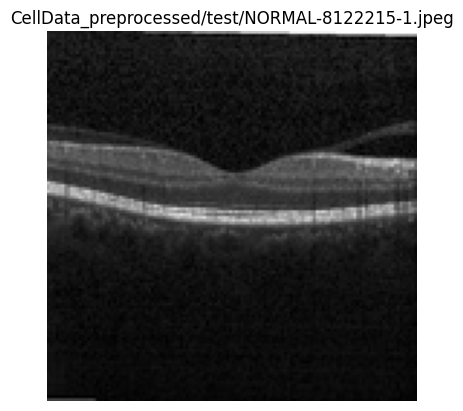

In [ ]:
plotimg(instance, MendeleyOCTDataset.CLASSES[label])

In [ ]:
import numpy as np
import torch

# `instance` is assumed to be the tensor from the dataset (e.g. CxHxW or 1xCxHxW)
img = instance

# ensure tensor on CPU and detached
if isinstance(img, torch.Tensor):
    img = img.detach().cpu()
    # remove batch dim if present
    if img.ndim == 4 and img.shape[0] == 1:
        img = img.squeeze(0)
    # convert C,H,W -> H,W,C
    if img.ndim == 3 and img.shape[0] in (1, 3):
        img = img.permute(1, 2, 0)
    img = img.numpy()

# ensure numpy array
img = np.array(img)

# handle single-channel images (make RGB)
if img.ndim == 2:
    img = np.stack([img] * 3, axis=-1)
elif img.ndim == 3 and img.shape[2] == 1:
    img = np.repeat(img, 3, axis=2)

# normalize for display (scale to 0-1)
mn, mx = img.min(), img.max()
if mx > 1 or mn < 0:
    img = (img - mn) / (mx - mn + 1e-8)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"Label: {label}" if 'label' in globals() else None)
plt.show()

NameError: name 'instance' is not defined

In [1]:
from torchinfo import summary
from torchvision.models import (
    vgg16,
    vgg19,
    resnet152,
    densenet169,
    efficientnet_b0,
    mobilenet_v2, mobilenet_v3_large, mobilenet_v3_small,
)
from torch import nn
from utils import TransferLearning

In [2]:
models = {
    "vgg16": vgg16(),
    "vgg19": vgg19(),
    "resnet152": resnet152(),
    "densenet169": densenet169(),
    "efficientnet_b0": efficientnet_b0(),
    "mobilenet_v2": mobilenet_v2(),
    "mobilenet_v3_large": mobilenet_v3_large(),
    "mobilenet_v3_small": mobilenet_v3_small(),
}

In [3]:
OCT_INPUT_SIZE = (1, 3, 128, 128)

In [4]:
TransferLearning.replace_head("resnet152", models["resnet152"], 4)

In [5]:
summary(models["resnet152"], input_size=OCT_INPUT_SIZE, depth=1)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 4]                    --
├─Conv2d: 1-1                            [1, 64, 64, 64]           9,408
├─BatchNorm2d: 1-2                       [1, 64, 64, 64]           128
├─ReLU: 1-3                              [1, 64, 64, 64]           --
├─MaxPool2d: 1-4                         [1, 64, 32, 32]           --
├─Sequential: 1-5                        [1, 256, 32, 32]          215,808
├─Sequential: 1-6                        [1, 512, 16, 16]          2,339,840
├─Sequential: 1-7                        [1, 1024, 8, 8]           40,613,888
├─Sequential: 1-8                        [1, 2048, 4, 4]           14,964,736
├─AdaptiveAvgPool2d: 1-9                 [1, 2048, 1, 1]           --
├─Linear: 1-10                           [1, 4]                    8,196
Total params: 58,152,004
Trainable params: 58,152,004
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 3.76
In